In [92]:
import pandas as pd
import numpy as np

df = pd.read_parquet('../data/raw/yellow_tripdata_2024-01.parquet')

Why Parquet is used ?

Kaggle provides the data in .parquet format , and apprantly it is much easier to load than .csv files , and is pretty common in ML/data engineering pipelines

In [93]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [94]:
df.shape

(2964624, 19)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [96]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2.964624e+06,2964624,2964624,2.824462e+06,2.964624e+06,2.824462e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06,2.824462e+06
mean,1.754204e+00,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.339281e+00,3.652169e+00,2.069359e+00,1.660179e+02,1.651167e+02,1.161271e+00,1.817506e+01,1.451598e+00,4.833823e-01,3.335870e+00,5.270212e-01,9.756319e-01,2.680150e+01,2.256122e+00,1.411611e-01
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-8.000000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.538000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.000000e+00,1.680000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.700000e+00,0.000000e+00,1.000000e+00,2.010000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.000000e+00,3.110000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.120000e+00,0.000000e+00,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,4.000000e+00,4.280000e+02,1.159200e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.325902e-01,NaN,NaN,8.502817e-01,2.254626e+02,9.823219e+00,6.362391e+01,6.931535e+01,5.808686e-01,1.894955e+01,1.804102e+00,1.177600e-01,3.896551e+00,2.128310e+00,2.183645e-01,2.338558e+01,8.232747e-01,4.876239e-01


DataFrame df holds around 3 million rows of data , for sampling we will take around 200K of rows 

In [97]:
df_sample = df.sample(n=200000,random_state=1)
df_sample

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
656247,2,2024-01-08 22:35:10,2024-01-08 22:46:04,1.0,2.93,1.0,N,142,90,4,-14.9,-1.0,-0.5,0.00,0.00,-1.0,-19.90,-2.5,0.00
1984133,2,2024-01-23 12:31:32,2024-01-23 12:45:26,2.0,1.25,1.0,N,230,48,2,13.5,0.0,0.5,0.00,0.00,1.0,17.50,2.5,0.00
2192612,2,2024-01-25 14:37:34,2024-01-25 15:15:01,1.0,15.65,1.0,N,132,80,1,61.8,0.0,0.5,16.26,0.00,1.0,81.31,0.0,1.75
2946811,1,2024-01-27 19:10:44,2024-01-27 19:20:51,NaN,1.50,NaN,None,43,239,0,11.4,2.5,0.5,3.58,0.00,1.0,21.48,NaN,NaN
124735,2,2024-01-02 18:47:41,2024-01-02 19:10:01,1.0,3.67,1.0,N,164,239,1,22.6,2.5,0.5,2.04,0.00,1.0,31.14,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2137999,1,2024-01-24 21:07:53,2024-01-24 21:19:03,1.0,2.40,1.0,N,166,239,2,12.8,3.5,0.5,0.00,0.00,1.0,17.80,2.5,0.00
2143658,1,2024-01-24 22:26:22,2024-01-24 22:38:24,1.0,2.10,1.0,N,163,238,1,12.1,3.5,0.5,3.40,0.00,1.0,20.50,2.5,0.00
2783591,2,2024-01-31 17:22:10,2024-01-31 17:41:35,2.0,1.22,1.0,N,137,186,2,17.0,2.5,0.5,0.00,0.00,1.0,23.50,2.5,0.00
150567,2,2024-01-03 07:33:15,2024-01-03 08:19:11,2.0,16.82,2.0,N,132,170,1,70.0,0.0,0.5,16.19,6.94,1.0,98.88,2.5,1.75


In [98]:
df_sample.to_parquet('../data/raw/yellow_tripdata_sample.parquet')

In [99]:
df = df_sample.copy()

#### Physically Impossible Values
fare_amount < 0 , total_amount < 0 , trip_distance < 0 , dropoff_time > pickup_time
 
At this stage, the goal is to identify and quantify such rows without correcting them.
No imputation or transformation is applied yet to avoid masking upstream data quality issues.
Correction strategy (drop vs NaN) will be decided based on prevalence.

In [100]:
target_cols = [
	'fare_amount',
	'total_amount',
	'tip_amount',
	'tolls_amount'
]
neg = df[target_cols]<0
neg_counts = neg.sum()
neg_counts


fare_amount     2539
total_amount    2397
tip_amount         9
tolls_amount     125
dtype: int64

In [101]:
invalid_time = df['tpep_dropoff_datetime'] < df['tpep_pickup_datetime']
invalid_time.sum()

np.int64(4)

Physically impossible -> dropped

In [102]:
df=df[~invalid_time].copy()
(df['tpep_dropoff_datetime'] < df['tpep_pickup_datetime']).sum()

np.int64(0)

In [103]:
zero_passenger=df['passenger_count']==0
zero_passenger.sum()

np.int64(2165)

In [104]:
df[zero_passenger]['trip_distance'].describe()

count    2165.000000
mean        2.597506
std         3.457892
min         0.000000
25%         0.900000
50%         1.600000
75%         2.600000
max        31.300000
Name: trip_distance, dtype: float64


We assume that probably the no. of passengers was not registered , because the trip_distance is loking to be normal

In [105]:
large_passenger=df['passenger_count']>6
large_passenger.sum()

np.int64(3)

Very small no. of passengers are above 6 , which is not physically possible , so dropping them

In [106]:
df=df[~large_passenger].copy()
(df['passenger_count']>6).sum()

np.int64(0)

In [107]:
zero_distance=df['trip_distance']==0
zero_distance.sum()

np.int64(4116)

In [108]:
(df[zero_distance]['fare_amount']>0).sum()

np.int64(3843)

In [109]:
(df[zero_distance]['fare_amount']<0).sum()

np.int64(257)

In [110]:
for col in target_cols :
	df.loc[df[col]<0] = np.nan

(df[target_cols]<0).sum()

fare_amount     0
total_amount    0
tip_amount      0
tolls_amount    0
dtype: int64

### Cleaning decisions :

Dropped invalid time rows (4)

Negative monetary values → set to NaN

passenger_count == 0 → treated as unknown, retained

passenger_count > 6 → dropped

Zero-distance trips → retained, documented anomaly

In [112]:
df['pickup_hour']=df['tpep_pickup_datetime'].dt.hour
df['pickup_day']=df['tpep_pickup_datetime'].dt.day_name()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,pickup_day
656247,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984133,2.0,2024-01-23 12:31:32,2024-01-23 12:45:26,2.0,1.25,1.0,N,230.0,48.0,2.0,...,0.0,0.5,0.00,0.0,1.0,17.50,2.5,0.00,12.0,Tuesday
2192612,2.0,2024-01-25 14:37:34,2024-01-25 15:15:01,1.0,15.65,1.0,N,132.0,80.0,1.0,...,0.0,0.5,16.26,0.0,1.0,81.31,0.0,1.75,14.0,Thursday
2946811,1.0,2024-01-27 19:10:44,2024-01-27 19:20:51,NaN,1.50,NaN,None,43.0,239.0,0.0,...,2.5,0.5,3.58,0.0,1.0,21.48,NaN,NaN,19.0,Saturday
124735,2.0,2024-01-02 18:47:41,2024-01-02 19:10:01,1.0,3.67,1.0,N,164.0,239.0,1.0,...,2.5,0.5,2.04,0.0,1.0,31.14,2.5,0.00,18.0,Tuesday


Text(0, 0.5, 'No. of Trips')

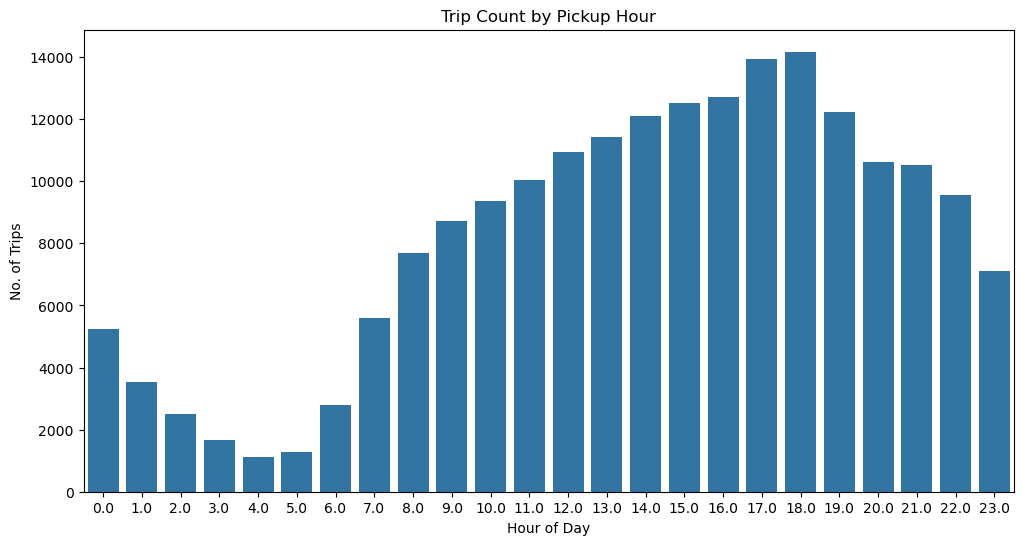

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(x='pickup_hour',data=df)
plt.title('Trip Count by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('No. of Trips')

Trip count clearly shows the structure with peaks from afternoon to evening hours indicating alignment with regular workday travels , Night Life and Airport travel is suggested by the night hours .

Text(0, 0.5, 'No. of Trips')

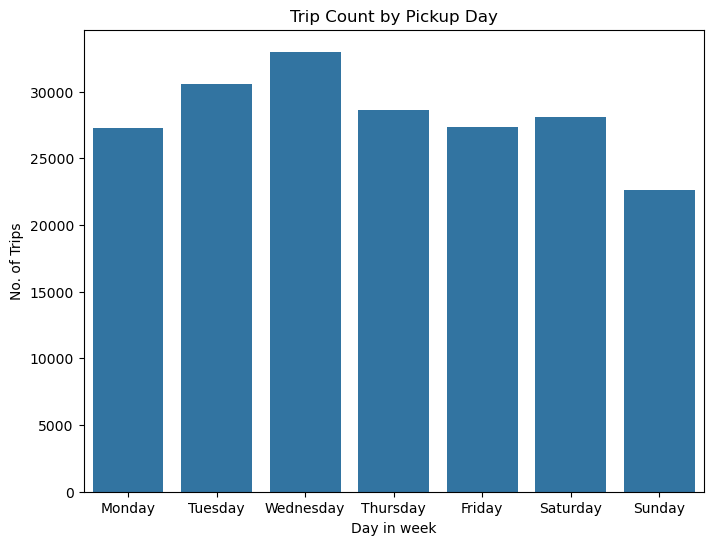

In [122]:
weekday=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(8,6))
sns.countplot(x='pickup_day',data=df,order=weekday)
plt.title('Trip Count by Pickup Day')
plt.xlabel('Day in week')
plt.ylabel('No. of Trips')

Trip Volume is considerably higher on weekdays than weekends , they must be daily-office driven tasks . Weekends suggests additional leisure driven usage.

Text(0, 0.5, 'Number of Trips')

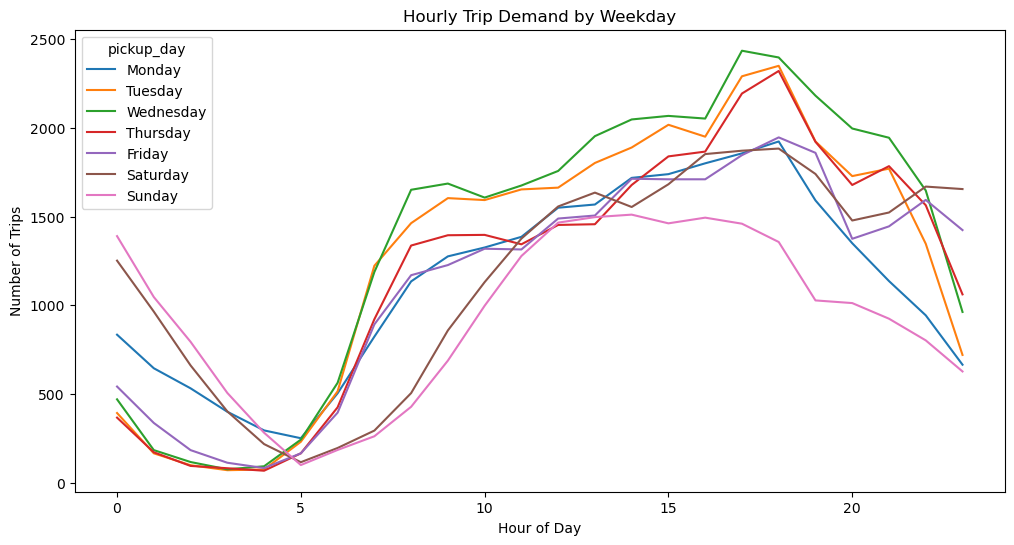

In [144]:
weekdays=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

hour_weekday = (
    df.groupby(['pickup_day','pickup_hour'])
      .size()
      .reset_index(name='trips')
)

hour_weekday['pickup_day']=pd.Categorical(
    hour_weekday['pickup_day'],
    categories=weekdays,
    ordered=True
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=hour_weekday,
    x='pickup_hour',
    y='trips',
    hue='pickup_day'
)

plt.title('Hourly Trip Demand by Weekday')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

### Insights

Taxi demand shows strong hourly seasonality, with clear peaks during daytime and evening hours.

Demand patterns differ across weekdays, with weekends exhibiting relatively stronger late-night activity.

Temporal features such as pickup hour and day of week are likely to be informative predictors for downstream demand or fare modeling.

Text(0.5, 0, 'Fare Amount')

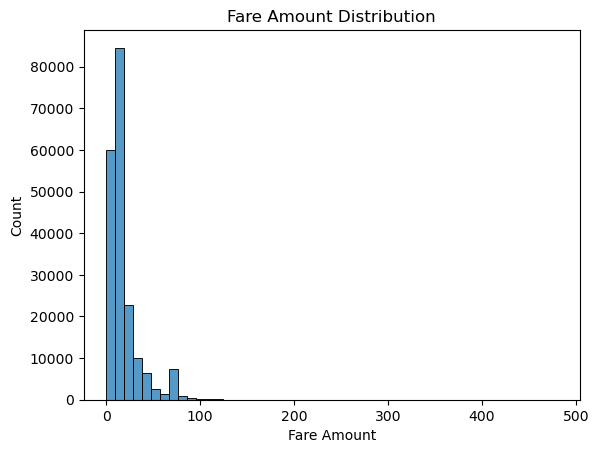

In [148]:
sns.histplot(df['fare_amount'],bins=50)
plt.title('Fare Amount Distribution')
plt.xlabel('Fare Amount')


Fare amounts exhibit strong right skew with a long tail of high-value trips, indicating the presence of outliers and non-normality

Text(0.5, 0, 'log(Fare Amount + 1)')

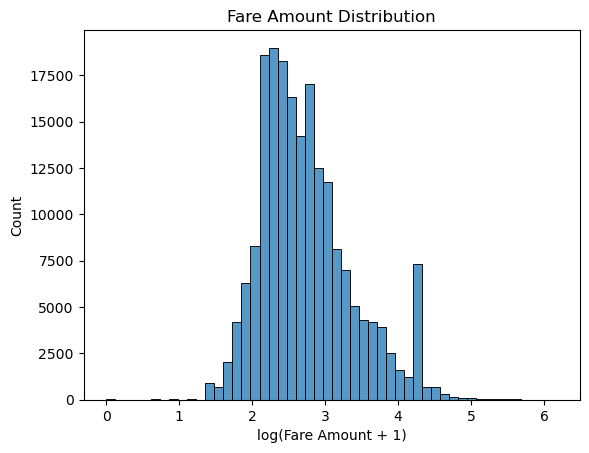

In [150]:
sns.histplot(np.log1p(df['fare_amount']),bins=50)
plt.title('Fare Amount Distribution')
plt.xlabel('log(Fare Amount + 1)')

Log-scaling removes the skewnessand reveals a more compact distribution

Text(0.5, 1.0, 'Fare vs Trip Distance')

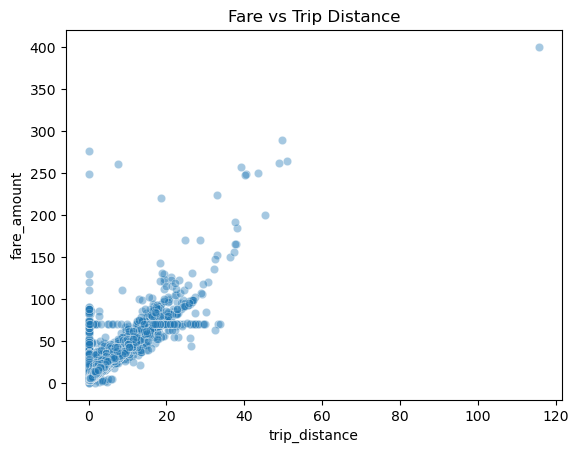

In [156]:
plot_df = df.sample(20000,random_state=1)
sns.scatterplot(x='trip_distance',y='fare_amount',data=plot_df,alpha=0.4)
plt.title('Fare vs Trip Distance')

Fare generally increases with trip distance , though the plot is noisy in small distances due to minimum fare . Vertical clusters at the distance 0 is treated as unknown rather than distance zero

### Insights : 
Fare is highly right-skewed , with a long tail of high-value trips

Distance has a strong influence on fare , minimum fare affects introduces noise at shorter distances


Text(0.5, 1.0, 'Passenger Count Distribution')

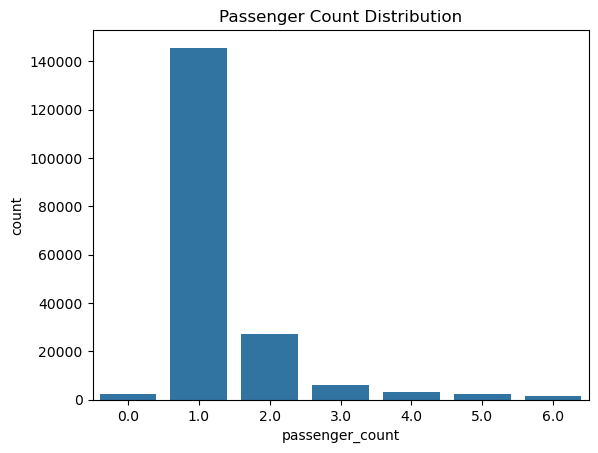

In [162]:
sns.countplot(x='passenger_count',data=df)
plt.title('Passenger Count Distribution')

Most Trips involves one or two passengers , with rapidly descreasing frequency for larger passenger groups . Zero passenger count represnts the unregistered/unknown passenger counts rather than true 0 passenger count

Text(0.5, 1.0, 'Trip Distance by Passenger Count')

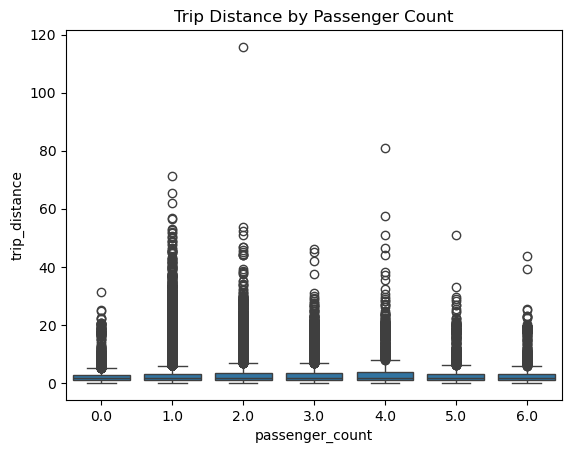

In [177]:
sns.boxplot(x='passenger_count',y='trip_distance',data=df)
plt.title('Trip Distance by Passenger Count')

A boxplot of trip distance by passenger count was found to be dominated by extreme outliers and skewness, making comparisons difficult.

Text(0.5, 0, 'Passenger count')

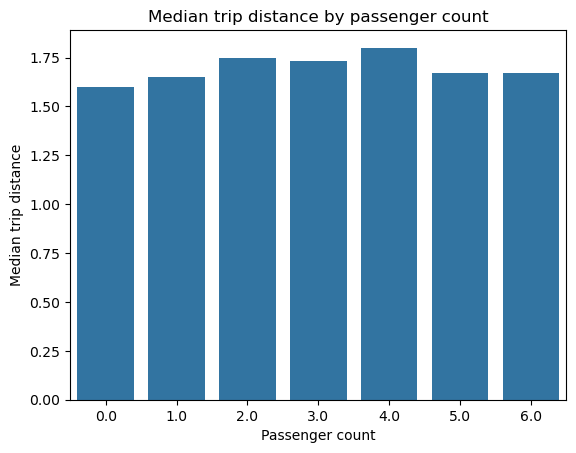

In [172]:
sns.barplot(x='passenger_count',y='trip_distance',data=df,estimator=np.median,errorbar=None)
plt.title('Median trip distance by passenger count')
plt.ylabel('Median trip distance')
plt.xlabel('Passenger count')

Text(0.5, 1.0, 'Distribution of Payment Type')

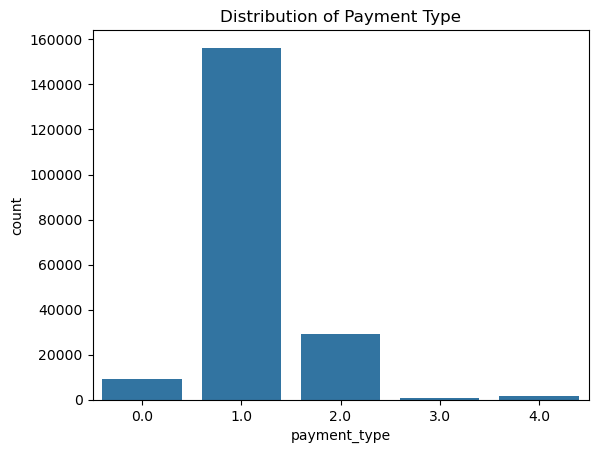

In [174]:
sns.countplot(x='payment_type',data=df)
plt.title('Distribution of Payment Type')

Payment Type is highly imbalanced , with one highly dominant category over others

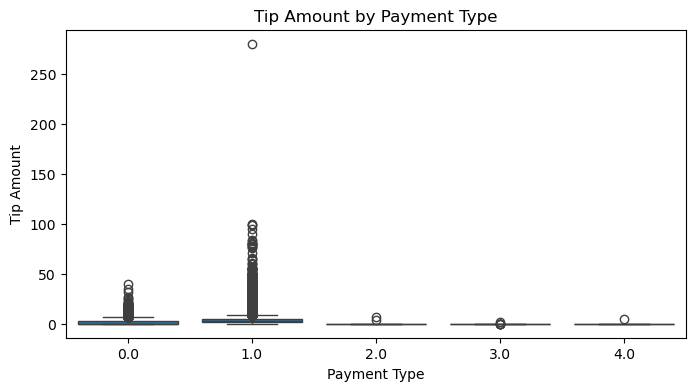

In [187]:
plt.figure(figsize=(8,4))
sns.boxplot(x='payment_type', y='tip_amount', data=df)
plt.title('Tip Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Tip Amount')
plt.show()


Tipping behavior varies significantly by payment type, with some methods showing consistently low or zero tips. This indicates that payment type may be an important contextual feature when analyzing or modeling tipping behavior.

## KEY FINDINGS

1. Taxi demand exhibit strong hourly variance with pronounced weekday commute peaks and week-ends late night behaviour.

2. Fare amounts are highly right-skewed which shows presence of outliers and non-normal behaviour.

3. Trip Distance is primary factor in Fare distribution , though short trip distance introduces noise.

4. Passenger Count is dominated by low values (1-2) , zero passenger number indicates unknown passenger count.

5. Payment type distribution is highly imbalanced , and tipping behaviour varies among payment methods.


## DATA CLEANING SUMMARY

1. Dropped trips with invalid temporal order (pickup time comes after dropoff time).
2. Set negative columns values to NaN to avoid distorting distributions
3. Retained passenger_count = 0 as an indicator of unknown/missing data due to valid trip metrics.
4. Retained zero distance trips as documented operational anomalies. 